In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from skimage import color, io

image_url = "download.jpg"
image = io.imread(image_url)

In [2]:
gray_image = color.rgb2gray(image)
original_shape = gray_image.shape

In [3]:
pca = PCA(n_components=50)  
transformed = pca.fit_transform(gray_image)

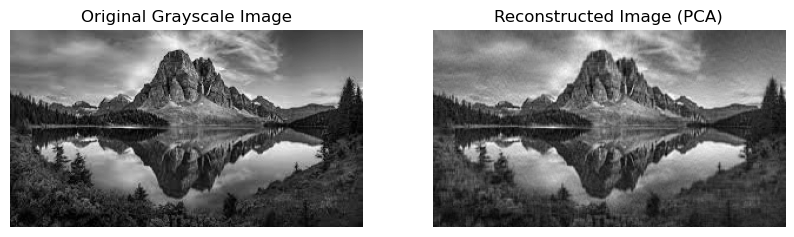

In [4]:
reconstructed = pca.inverse_transform(transformed)

fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(gray_image, cmap="gray")
ax[0].set_title("Original Grayscale Image")
ax[0].axis("off")

ax[1].imshow(reconstructed, cmap="gray")
ax[1].set_title("Reconstructed Image (PCA)")
ax[1].axis("off")

plt.show()

In [5]:
transformed.shape

(168, 50)

In [6]:
image = io.imread("download.jpg") 

In [7]:
if image.shape[-1] == 4:  
    image = image[..., :3]

In [8]:
def apply_pca(image, n_components=50):
    reconstructed_channels = []
    for i in range(3): 
        channel = image[:, :, i]
        pca = PCA(n_components=n_components)
        transformed = pca.fit_transform(channel)  
        reconstructed = pca.inverse_transform(transformed)  
        reconstructed_channels.append(reconstructed)
    
    return np.stack(reconstructed_channels, axis=2).astype(np.uint8)

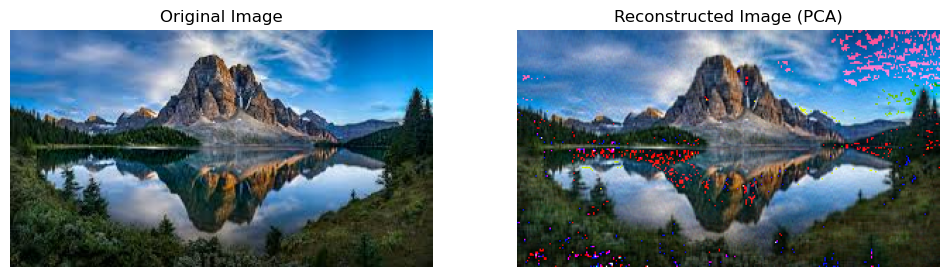

In [9]:
reconstructed_image = apply_pca(image, n_components=50)

fig, ax = plt.subplots(1, 2, figsize=(12, 6))
ax[0].imshow(image)
ax[0].set_title("Original Image")
ax[0].axis("off")

ax[1].imshow(reconstructed_image)
ax[1].set_title("Reconstructed Image (PCA)")
ax[1].axis("off")

plt.show()